In [1]:
# Geneva Cycle & Pedestrian Network Analysis
# -------------------------------------------------
# This script downloads OpenStreetMap data for the Canton of Geneva, then
# computes the share (in linear metres and estimated surface) of bicycle lanes
# and pedestrian‑dedicated paths relative to the overall road network. Finally,
# it renders two minimalist maps à la Action Située.
# -------------------------------------------------
# Usage (from a notebook or terminal):
#   %run geneva_cyclability_analysis.py
# or simply execute the cells step by step if you paste it in a notebook.
# -------------------------------------------------
import osmnx as ox
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt


In [14]:

# -------------------------------------------------
# 1. Fetch the canton boundary and project to a Swiss metric CRS (LV95 / EPSG:2056)
# -------------------------------------------------
area_name = "Geneva, Switzerland"
print(f"Downloading administrative boundary for: {area_name}")

boundary = ox.geocode_to_gdf(area_name)

#Ensure CRS is set and in WGS84
if boundary.crs is None:
    boundary.set_crs("EPSG:4326", inplace=True)
else:
    boundary = boundary.to_crs("EPSG:4326")

#Combine into a single polygon (recommended)
polygon = boundary.geometry.union_all()

In [19]:

# -------------------------------------------------
# 2. Retrieve the full network of linear OSM features inside the canton
#    We work with the `all_private` network to keep everything that could be
#    considered navigable (roads, paths, etc.)
# -------------------------------------------------
print("Fetching OSM network … this can take a minute or two")
G_all = ox.graph_from_polygon(polygon, network_type="all", simplify=True)

edges_all = ox.graph_to_gdfs(G_all, nodes=False, edges=True, fill_edge_geometry=True)
# Work in metres ➜ project
edges_all = edges_all.to_crs("EPSG:2056")

# -------------------------------------------------
# 3. Tag pedestrian‑exclusive segments
# -------------------------------------------------
#cycle_highways = {"cycleway"}
ped_highways   = {"footway", "pedestrian", "path", "steps"}

#cycle_edges = edges_all[(edges_all["highway"].isin(cycle_highways)) | edges_all["cycleway"].notna()]
ped_edges   = edges_all[edges_all["highway"].isin(ped_highways)]

# -------------------------------------------------
# 4. Compute linear metrics (metres)
# -------------------------------------------------
print("Computing lengths …")
length_total = edges_all["length"].sum()
#length_cycle = cycle_edges["length"].sum()
length_ped   = ped_edges["length"].sum()


Fetching OSM network … this can take a minute or two
Computing lengths …


In [23]:

# -------------------------------------------------
# 5. Very rough surface estimates using typical widths when explicit width=* is missing
#    (Feel free to update these heuristics with local standards!)
# -------------------------------------------------


def estimate_width(row):
    w = row.get("width")
    # Handle list/array widths
    if isinstance(w, (list, tuple)):
        # Try to use the first valid numeric value
        for val in w:
            try:
                return float(str(val).split(";")[0])
            except (ValueError, TypeError):
                continue
    elif pd.notnull(w):
        try:
            return float(str(w).split(";")[0])  # handle "3;3"
        except ValueError:
            pass

    hw = row["highway"]
    if isinstance(hw, list):
        if any(h in ped_highways for h in hw):
            return 2.0
    elif hw in ped_highways:
        return 2.0

    return 3.5  # default generic width

In [ ]:
print("Estimating widths and surfaces …")
edges_all["width_est"]  = edges_all.apply(estimate_width, axis=1)
#cycle_edges["width_est"] = cycle_edges.apply(estimate_width, axis=1)
ped_edges["width_est"]   = ped_edges.apply(estimate_width, axis=1)

surface_total = (edges_all["length"] * edges_all["width_est"]).sum()
#surface_cycle = (cycle_edges["length"] * cycle_edges["width_est"]).sum()
surface_ped   = (ped_edges["length"] * ped_edges["width_est"]).sum()

# -------------------------------------------------
# 6. Summaries
# -------------------------------------------------
#length_share_cycle = length_cycle / length_total * 100
length_share_ped   = length_ped   / length_total * 100

#surface_share_cycle = surface_cycle / surface_total * 100
surface_share_ped   = surface_ped   / surface_total * 100

print("\n=======================  RESULTS  =======================")
print(f"Total network length       : {length_total:,.0f} m")
#print(f" – Cycle‑dedicated length   : {length_cycle:,.0f} m  ({length_share_cycle:.2f} %)")
print(f" – Pedestrian‑dedicated len.: {length_ped:,.0f} m  ({length_share_ped:.2f} %)")
print("--------------------------------------------------------")
print(f"Total network surface       : {surface_total/1e6:,.2f} ha")
#print(f" – Cycle‑dedicated surface  : {surface_cycle/1e6:,.2f} ha ({surface_share_cycle:.2f} %)")
print(f" – Pedestrian‑dedicated surf: {surface_ped/1e6:,.2f} ha ({surface_share_ped:.2f} %)")
print("========================================================\n")


Estimating widths and surfaces …

=======================  RESULTS  =======================
Total network length       : 1,635,833 m
 – Pedestrian‑dedicated len.: 951,028 m  (58.14 %)
--------------------------------------------------------
Total network surface       : 4.21 ha
 – Pedestrian‑dedicated surf: 1.90 ha (45.16 %)



/Users/Helo/anaconda3/envs/actionsituee/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [ ]:
#check if the CRS is set correctly
print(boundary.crs)
print(edges_all.crs)
print(ped_edges.crs)

epsg:4326
EPSG:2056
EPSG:2056


In [ ]:
#correct the CRS if not epsg2056
if boundary.crs.to_epsg() != 2056:
    print("Reprojecting boundary to EPSG:2056")
    boundary = boundary.to_crs("EPSG:2056")


In [30]:
print(len(boundary))
print(len(edges_all))
print(len(ped_edges))

print(boundary.is_valid.all())
print(edges_all.is_valid.all())
print(ped_edges.is_valid.all())

1
60070
35912
True
True
True


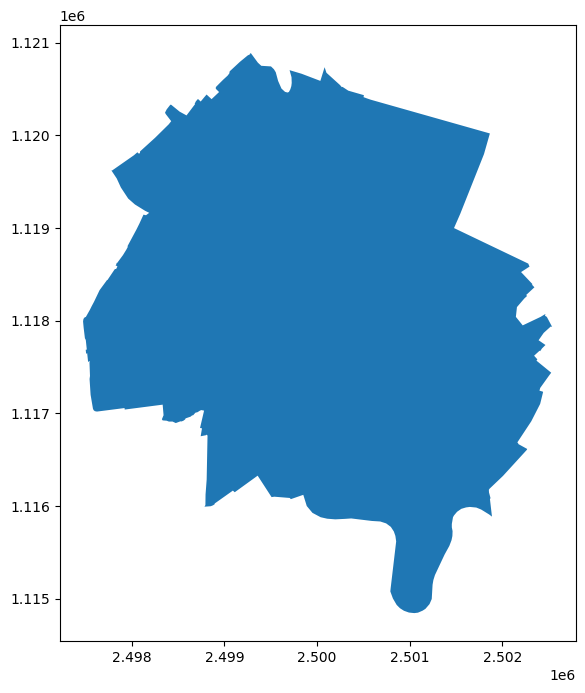

In [31]:
boundary.plot()
plt.show()

Drawing minimalist maps …


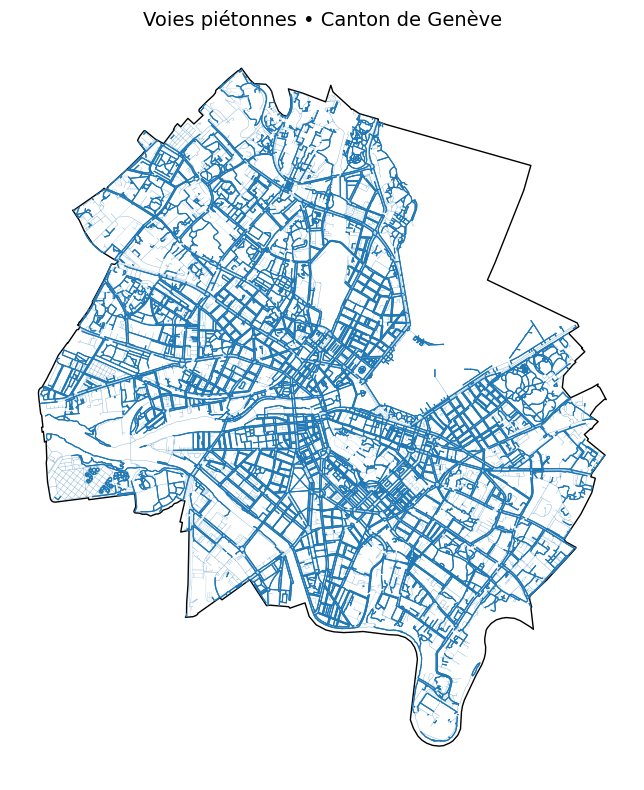

In [32]:

# -------------------------------------------------
# 7. Minimalist visualisations (static) – one map per mode
# -------------------------------------------------
print("Drawing minimalist maps …")
plt.rcParams["figure.figsize"] = (8, 8)

# Pedestrian paths map
ax2 = boundary.plot(facecolor="none")
edges_all.plot(ax=ax2, linewidth=0.3, alpha=0.3)
ped_edges.plot(ax=ax2, linewidth=0.8)
ax2.set_title("Voies piétonnes • Canton de Genève", fontsize=14)
ax2.set_axis_off()
plt.tight_layout()
plt.show()


In [ ]:
'''# Cycleways map
ax1 = boundary.plot(facecolor="none")
edges_all.plot(ax=ax1, linewidth=0.3, alpha=0.3)
cycle_edges.plot(ax=ax1, linewidth=0.8)
ax1.set_title("Cycleways • Canton de Genève", fontsize=14)
ax1.set_axis_off()
plt.tight_layout()
plt.show()'''